In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import yfinance as yf
from datetime import time
sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

# Para ir tocando data_cleaner sin tener que reiniciar el kernel
%load_ext autoreload
%autoreload 2

# Configuración para datos a 5m
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
   
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()
df = preprocess_data(df_raw)

df

,symbol,datetime,open,high,low,close,volume,trade_count,vwap,volume_norm,...,log_ret_ch,log_ret_cl,log_ret_vwap,log_return_lag1,log_return_lag3,log_return_lag5,vol_rolling,rsi,macd,macd_signal
0,QQQ,2022-01-03 10:40:00+00:00,400.0700,400.08,400.03,400.0300,928.0,26.0,400.053334,-1.038042,...,-0.000125,0.000000,-0.000083,0.000275,0.000200,-0.000100,0.000261,77.599999,0.000423,0.000313
1,QQQ,2022-01-03 10:45:00+00:00,400.0200,400.07,400.00,400.0700,1083.0,38.0,400.032727,-0.923369,...,0.000000,0.000175,-0.000052,-0.000200,-0.000200,0.000300,0.000260,76.666666,0.000430,0.000336
2,QQQ,2022-01-03 10:50:00+00:00,400.0100,400.07,399.96,400.0500,4364.0,43.0,400.017493,-0.269167,...,-0.000050,0.000225,-0.000038,0.000100,0.000275,0.000200,0.000255,75.206611,0.000427,0.000354
3,QQQ,2022-01-03 10:55:00+00:00,400.0700,400.07,400.07,400.0700,208.0,5.0,400.070000,-0.973547,...,0.000000,0.000000,0.000131,-0.000050,-0.000200,-0.000200,0.000225,73.451327,0.000424,0.000368
4,QQQ,2022-01-03 11:00:00+00:00,400.1500,400.40,400.15,400.3500,5741.0,83.0,400.314086,0.077401,...,-0.000125,0.000500,0.000610,0.000050,0.000100,0.000275,0.000257,77.272726,0.000472,0.000389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189326,QQQ,2026-01-01 00:35:00+00:00,614.2984,614.32,614.24,614.2639,635.0,48.0,614.287381,-0.986389,...,-0.000091,0.000039,0.000025,0.000016,-0.000080,0.000016,0.000053,41.026336,-0.000044,-0.000070
189327,QQQ,2026-01-01 00:40:00+00:00,614.3000,614.30,614.30,614.3000,129.0,12.0,614.300000,-1.211694,...,0.000000,0.000000,0.000021,-0.000059,-0.000018,0.000065,0.000053,48.699270,-0.000040,-0.000064
189328,QQQ,2026-01-01 00:45:00+00:00,614.2800,614.32,614.28,614.3085,991.0,48.0,614.301639,-0.593634,...,-0.000019,0.000046,0.000003,0.000059,0.000016,-0.000080,0.000053,49.948952,-0.000036,-0.000058
189329,QQQ,2026-01-01 00:50:00+00:00,614.2903,614.30,614.23,614.2400,4718.0,128.0,614.258774,1.783280,...,-0.000098,0.000016,-0.000070,0.000014,-0.000059,-0.000018,0.000059,42.378047,-0.000040,-0.000055


### Sanity Check: Correlación de las variable con la variable target

In [2]:
df.columns

Index(['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume',
       'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return',
       'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl',
       'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1',
       'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd',
       'macd_signal'],
      dtype='object')

## **Importacion de la variable de volatilidad GARCH**



In [3]:
from pathlib import Path

# --- Ajusta paths por si estás en notebook ---
ROOT = Path(".").resolve()
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Import robusto (según tengas el proyecto)
try:
    from GARCH import Garch11OOSBest
except Exception:
    from src.GARCH import Garch11OOSBest
    
    
# 1) Instanciar con los mismos params que tu script
m = Garch11OOSBest(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
    horizonte_horas=2,
    test_ratio=0.2,
    train_val_ratio=0.2,
    escala_returns=100.0,
    usar_horario_regular=True,
    usar_estacionalidad=True,
    season_smooth_half_window=5,
    fit_window_train_bars=16000,
    mean_mode="Zero",
    dist_mode="normal",
)

# 2) Pipeline interno (tal cual tu main)
m.cargar()
m.crear_target()
m.split()
m.ajustar_estacionalidad_train()
m.fit_train_fit()
m.filtrar_h_all()

# 3) Calcular sigma_2h para TODO el dataset (donde haya futuro suficiente)
df_g = m.df[["datetime"]].copy()
sig = np.full(len(df_g), np.nan, dtype=float)

# Nota: predecir_vol_futura_en_t devuelve None al final si no hay futuro.
for t in range(len(df_g)):
    out = m.predecir_vol_futura_en_t(t=t, devolver_path=False)
    if out is not None:
        sig[t] = out["sigma_2h"]

df_g["garch_vol_2h"] = sig
df_g = df_g.dropna(subset=["garch_vol_2h"]).reset_index(drop=True)

# 4) Guardar para reusar (evitas recomputar GARCH cada vez)
out_path = "garch_vol_2h_by_datetime.csv"
df_g.to_csv(out_path, index=False)

print("Saved:", out_path, "| rows:", len(df_g))
print("garch_vol_2h quantiles:", np.quantile(df_g["garch_vol_2h"].values, [0.01,0.05,0.1,0.5,0.9,0.95,0.99]))
print("head:\n", df_g.head(3).to_string(index=False))

>>> EJECUTANDO: GARCH(1,1) OOS BEST (H=2H) <<<
convergence_flag: 0
opt_message: Optimization terminated successfully

=== Params GARCH(1,1) (TRAIN_FIT) ===
omega=448.085739 alpha=0.100947 beta=0.875036 alpha+beta=0.975983 mu=0.000000
Saved: garch_vol_2h_by_datetime.csv | rows: 79167
garch_vol_2h quantiles: [0.00059981 0.00064707 0.00068026 0.00092084 0.00155706 0.00186155
 0.0027477 ]
head:
                  datetime  garch_vol_2h
2022-01-03 14:30:00+00:00      0.001302
2022-01-03 14:35:00+00:00      0.001278
2022-01-03 14:40:00+00:00      0.001240


In [4]:
HORIZON = 24  # 24 velas de 5m = 2 horas

# ratios (usa los mismos que tu pipeline)
TEST_RATIO = 0.20
VAL_RATIO  = 0.20  # dentro del tramo train (para calibrar umbrales en train_only)

# hiperparámetros del target
VOL_LOW_Q = 0.30   # "poca vol" = p30 de TRAIN
K_SIGMA   = 0.60   # umbral de retorno en "sigmas" de GARCH

df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# -------------------------
# 1) MERGE GARCH vol 2h
# -------------------------
df_g = pd.read_csv("garch_vol_2h_by_datetime.csv")
df_g["datetime"] = pd.to_datetime(df_g["datetime"], utc=True, errors="coerce")
df_g = df_g.dropna(subset=["datetime"]).sort_values("datetime")

df = df.merge(df_g[["datetime", "garch_vol_2h"]], on="datetime", how="left")
df = df.dropna(subset=["garch_vol_2h"]).reset_index(drop=True)

# -------------------------
# 2) TARGET (sin cruzar día NY)
# -------------------------
df["date_ny"] = df["datetime"].dt.tz_convert("America/New_York").dt.date
df["close_future"] = df.groupby("date_ny")["close"].shift(-HORIZON)
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

df["fwd_logret_2h"] = np.log(df["close_future"] / df["close"])

# -------------------------
# 3) Umbrales SOLO con TRAIN
# -------------------------
n = len(df)
corte_test = int(n * (1 - TEST_RATIO))
corte_val  = int(corte_test * (1 - VAL_RATIO))
df_train_only = df.iloc[:corte_val].copy()

vol_low = float(df_train_only["garch_vol_2h"].quantile(VOL_LOW_Q))
thr_dyn = K_SIGMA * df["garch_vol_2h"].values

# clases: 0=DOWN, 1=FLAT, 2=UP
df["direction_2h"] = 1  # por defecto FLAT

# si vol baja => FLAT (lateral)
low_vol_mask = (df["garch_vol_2h"].values <= vol_low)

# si no vol baja, decide por umbral dinamico
hi_vol_mask = ~low_vol_mask
df.loc[hi_vol_mask & (df["fwd_logret_2h"].values >  thr_dyn), "direction_2h"] = 2
df.loc[hi_vol_mask & (df["fwd_logret_2h"].values < -thr_dyn), "direction_2h"] = 0
df["direction_2h"] = df["direction_2h"].astype(np.int8)

# Limpieza auxiliares
df = df.drop(columns=[c for c in ["close_future", "date_ny"] if c in df.columns])

print("vol_low (train p30) =", vol_low)
print("Frac low_vol =", float(low_vol_mask.mean()))
print("Class dist:", df["direction_2h"].value_counts(normalize=True).sort_index().to_dict())
print("Rows df:", len(df))


vol_low (train p30) = 0.00082625699907681
Frac low_vol = 0.3538978128686814
Class dist: {0: 0.2729285779108812, 1: 0.42261548234867047, 2: 0.3044559397404483}
Rows df: 55095


In [5]:
DOWN, FLAT, UP = 0, 1, 2

TEST_RATIO = 0.20
VAL_RATIO  = 0.20

n = len(df)
corte_test = int(n * (1 - TEST_RATIO))
corte_val  = int(corte_test * (1 - VAL_RATIO))
df_train_only = df.iloc[:corte_val].copy()

qs = [0.20, 0.25, 0.30, 0.35]
ks = [0.50, 0.60, 0.70, 0.80]

rows = []
vol = df["garch_vol_2h"].values
ret = df["fwd_logret_2h"].values

for q in qs:
    vol_low = float(df_train_only["garch_vol_2h"].quantile(q))
    low_vol_mask = (vol <= vol_low)

    for k in ks:
        thr = k * vol
        y = np.full(len(df), FLAT, dtype=np.int8)

        hi = ~low_vol_mask
        y[hi & (ret >  thr)] = UP
        y[hi & (ret < -thr)] = DOWN

        # dist global (rápido)
        p0 = float(np.mean(y == DOWN))
        p1 = float(np.mean(y == FLAT))
        p2 = float(np.mean(y == UP))
        nonflat = 1.0 - p1

        rows.append((q, k, vol_low, float(low_vol_mask.mean()), p0, p1, p2, nonflat))

res = pd.DataFrame(rows, columns=[
    "VOL_LOW_Q","K_SIGMA","vol_low","frac_low_vol","p_down","p_flat","p_up","nonflat"
])

# Filtro “razonable”: FLAT entre 0.33 y 0.48 y noflat >= 0.45 y clases laterales no ridículas
good = res[(res["p_flat"].between(0.33, 0.48)) & (res["nonflat"] >= 0.45)]
good = good.sort_values(["nonflat","p_flat"], ascending=[False, True])

print("TOP combos:")
print(good.head(12).to_string(index=False))

print("\nAll combos (si quieres verlos):")
print(res.sort_values(["p_flat"], ascending=True).to_string(index=False))


TOP combos:
 VOL_LOW_Q  K_SIGMA  vol_low  frac_low_vol   p_down   p_flat     p_up  nonflat
      0.20      0.6 0.000765      0.253707 0.312206 0.334350 0.353444 0.665650
      0.20      0.7 0.000765      0.253707 0.306253 0.347164 0.346583 0.652836
      0.20      0.8 0.000765      0.253707 0.300009 0.360051 0.339940 0.639949
      0.25      0.5 0.000795      0.303839 0.298902 0.366422 0.334676 0.633578
      0.25      0.6 0.000795      0.303839 0.292749 0.378655 0.328596 0.621345
      0.25      0.7 0.000795      0.303839 0.287195 0.390471 0.322334 0.609529
      0.25      0.8 0.000795      0.303839 0.281350 0.402378 0.316272 0.597622
      0.30      0.5 0.000826      0.353898 0.278646 0.411308 0.310046 0.588692
      0.30      0.6 0.000826      0.353898 0.272929 0.422615 0.304456 0.577385
      0.30      0.7 0.000826      0.353898 0.267919 0.433488 0.298593 0.566512
      0.30      0.8 0.000826      0.353898 0.262492 0.444360 0.293148 0.555640
      0.35      0.5 0.000857      0.4033

In [6]:
HORIZON = 24  # 24 velas de 5m = 2 horas
df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# TARGET

## Aseguramos el horario de Nueva York
df["date_ny"] = df["datetime"].dt.tz_convert("America/New_York").dt.date

# el close future no es mas que el precio futuro que se quiere predecir (Esta vez de  la columna date_ny, que indica el del horario de nueva york)
df["close_future"] = df.groupby("date_ny")["close"].shift(-HORIZON)

# elimina las ultimas filas ya que no tenemos datos de ses futuro
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

# la variable direccion compara el precio futuro con el actual, si es mayor guarda 1, y si es menor o igual 0
thr = 0.0005
df["fwd_logret_2h"] = np.log(df["close_future"] / df["close"])

df["direction_2h"] = 1
df.loc[df["fwd_logret_2h"] >  thr, "direction_2h"] = 2
df.loc[df["fwd_logret_2h"] < -thr, "direction_2h"] = 0
df["direction_2h"] = df["direction_2h"].astype(np.int8)

FEATURE_COLUMNS = df.select_dtypes(include=["int64","int32","float64","float32","int8","int16","float16"]).columns.tolist()

unuseful_features = [
    "open", "high", "low", "close", "fwd_logret_2h", "close_future"
]

FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if not c in unuseful_features]

# quitar las que no existan (por si Alpaca/YF no trae alguna)
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in df.columns]

# Limpieza de columnas auxiliares
df = df.drop(columns=[c for c in ["close_future", "date_ny"] if c in df.columns])

print("N features:", len(FEATURE_COLUMNS))
print("FEATURE_COLUMNS:", FEATURE_COLUMNS)
print("Rows df:", len(df))

print("direction_2h" in df.columns)
print(df[["close", "direction_2h"]].head())
 

N features: 22
FEATURE_COLUMNS: ['volume', 'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'garch_vol_2h', 'direction_2h']
Rows df: 31040
True
      close  direction_2h
0  400.4200             0
1  401.0600             0
2  400.5600             0
3  398.2175             2
4  397.3500             2


### Matriz de Correlacion

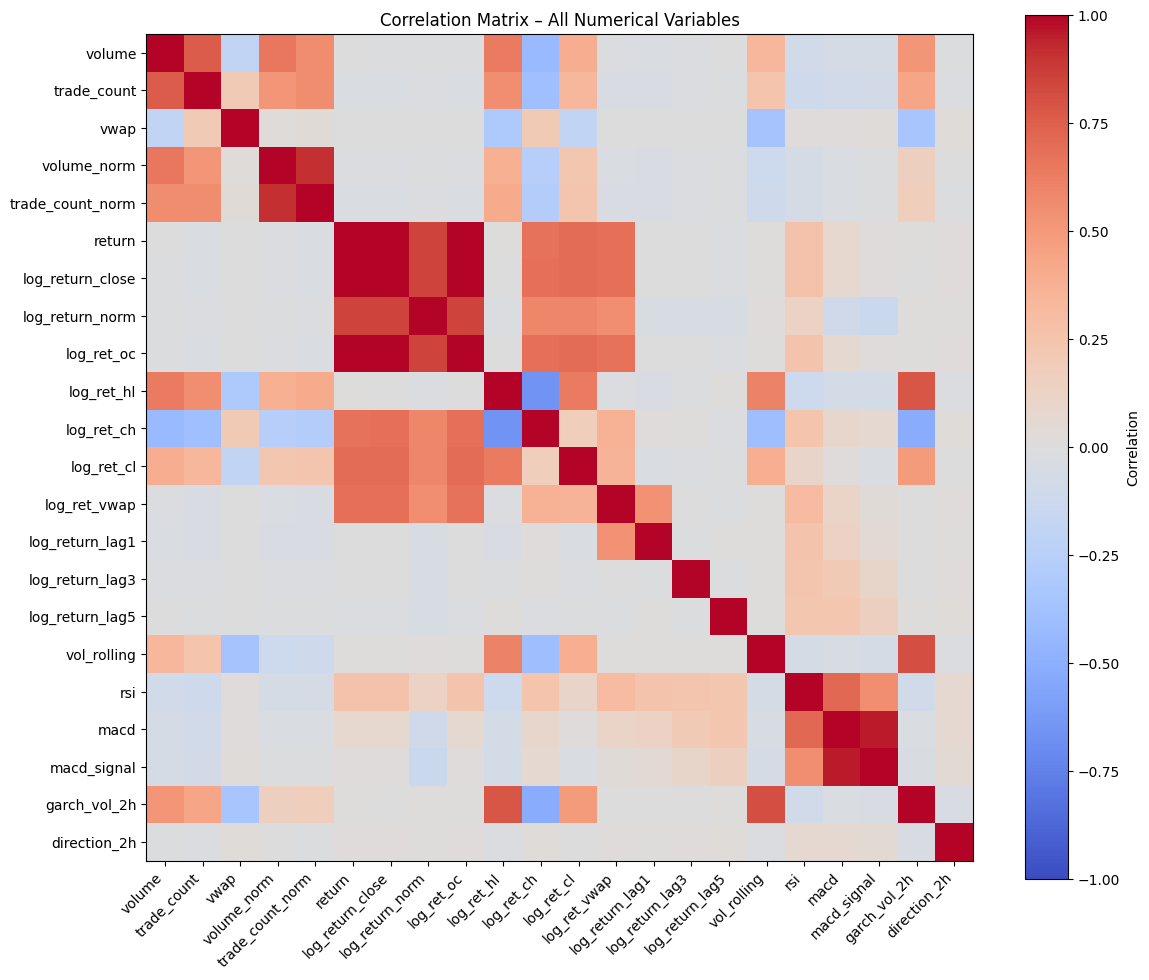

In [7]:
corr_all = df[FEATURE_COLUMNS].corr()
corr_all["direction_2h"].sort_values(ascending=False)


corr_all = df[FEATURE_COLUMNS].corr()

corr_all

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))
plt.imshow(corr_all, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_all.columns)), corr_all.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_all.index)), corr_all.index)

plt.title("Correlation Matrix – All Numerical Variables")
plt.tight_layout()
plt.show()


In [23]:
df_final = df[FEATURE_COLUMNS + ["direction_2h"]]

print(df_final.columns)

Index(['volume', 'trade_count', 'vwap', 'volume_norm', 'trade_count_norm',
       'return', 'log_return_close', 'log_return_norm', 'log_ret_oc',
       'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap',
       'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling',
       'rsi', 'macd', 'macd_signal', 'garch_vol_2h', 'direction_2h'],
      dtype='object')


### Función de selección por correlación

In [24]:
def select_features_by_correlation(
    df,
    feature_cols,
    target_col,
    min_corr_target=0.02,
    max_corr_between=0.9
):
    """
    Selecciona features útiles según:
    - correlación mínima con el target
    - no redundancia entre features
    """

    # 1) correlación con el target
    corr_target = (
        df[feature_cols + [target_col]]
        .corr()[target_col]
        .drop(target_col)
        .abs()
        .sort_values(ascending=False)
    )

    # 2) filtrado por correlación mínima con target
    selected = corr_target[corr_target >= min_corr_target].index.tolist()

    # 3) eliminar redundancia entre features
    corr_features = df[selected].corr().abs()
    final_features = []

    for f in selected:
        keep = True
        for g in final_features:
            if corr_features.loc[f, g] > max_corr_between:
                keep = False
                break
        if keep:
            final_features.append(f)

    return final_features, corr_target


In [25]:
num_cols , corr_target = select_features_by_correlation(
    df_final,
    FEATURE_COLUMNS,
    target_col="direction_2h",
    min_corr_target=0.02,
    max_corr_between=0.9
)

print("Selected features:", num_cols)
print("\nCorrelation with target:")
print(corr_target)

Selected features: ['macd', 'rsi', 'garch_vol_2h', 'log_ret_ch', 'log_ret_hl', 'vol_rolling', 'log_return_lag5']

Correlation with target:
macd                0.057164
rsi                 0.056147
macd_signal         0.052994
garch_vol_2h        0.033118
log_ret_ch          0.022474
log_ret_hl          0.021717
vol_rolling         0.020820
log_return_lag5     0.020309
vwap                0.018055
trade_count         0.015923
log_return_lag3     0.015103
volume              0.014525
log_return_close    0.011108
log_ret_oc          0.011082
return              0.011050
trade_count_norm    0.009772
log_ret_vwap        0.009729
log_return_lag1     0.006403
volume_norm         0.006117
log_ret_cl          0.005295
log_return_norm     0.000968
Name: direction_2h, dtype: float64


In [ ]:
# Define fechas clave para el test/val/train
VAL_START  = pd.Timestamp("2024-09-01", tz="UTC")
TEST_START = pd.Timestamp("2025-01-01", tz="UTC")
TEST_END   = pd.Timestamp("2026-01-01", tz="UTC")  # exclusivo

embargo = pd.Timedelta(hours=2)  # = horizonte (2h)

# Marca los limites del dataframe de train y de val
TRAIN_END = VAL_START - embargo
VAL_END   = TEST_START - embargo

# Creamos los dataframes de train/val/test
# val es el test real y test es el backtest que se usa para ver si la estrategia es viable a lo largo del tiempo
df_train = df[df["datetime"] < TRAIN_END].copy()
df_val   = df[(df["datetime"] >= VAL_START) & (df["datetime"] < VAL_END)].copy()
df_test  = df[(df["datetime"] >= TEST_START) & (df["datetime"] < TEST_END)].copy()

print("train:", df_train["datetime"].min(), "->", df_train["datetime"].max(), "| rows:", len(df_train))
print("val:  ", df_val["datetime"].min(),   "->", df_val["datetime"].max(),   "| rows:", len(df_val))
print("test: ", df_test["datetime"].min(),  "->", df_test["datetime"].max(),  "| rows:", len(df_test))

print("P(y=1) train:", df_train["direction_2h"].mean())
print("P(y=1) val:  ", df_val["direction_2h"].mean())
print("P(y=1) test: ", df_test["direction_2h"].mean())

train: 2022-01-03 14:30:00+00:00 -> 2024-08-30 16:00:00+00:00 | rows: 20722
val:   2024-09-03 13:30:00+00:00 -> 2024-12-31 17:00:00+00:00 | rows: 2600
test:  2025-01-02 14:30:00+00:00 -> 2025-12-30 17:00:00+00:00 | rows: 7718
P(y=1) train: 1.0554965736897983
P(y=1) val:   1.0903846153846153
P(y=1) test:  1.1015807203938843


### Sanity Check: clase target alineada en el tiempo
Realizaremos un Snaity Check para ver si la clase direction_2h esta alineada o no en el tiempo

In [27]:
# Sanity Check para variable direction_2h

idx = 1000

print(len(df))
print(df.index[:5])
print(df.index[-5:])
print(1000 in df.index)


df.loc[idx, ["datetime", "close", "direction_2h"]]



31040
RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=31035, stop=31040, step=1)
True


datetime        2022-02-17 15:10:00+00:00
close                            351.4255
direction_2h                            0
Name: 1000, dtype: object

In [28]:
from sklearn.preprocessing import StandardScaler

# ---------- scaler para LSTM (solo FEATURE_COLUMNS) ----------
scaler_feats = StandardScaler()

X_train_raw = df_train[FEATURE_COLUMNS].values
X_val_raw   = df_val[FEATURE_COLUMNS].values
X_test_raw  = df_test[FEATURE_COLUMNS].values

X_train_scaled = scaler_feats.fit_transform(X_train_raw)
X_val_scaled   = scaler_feats.transform(X_val_raw)
X_test_scaled  = scaler_feats.transform(X_test_raw)

df_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
df_train_scaled["datetime"] = df_train["datetime"].values
df_train_scaled["direction_2h"] = df_train["direction_2h"].values

df_val_scaled = pd.DataFrame(X_val_scaled, columns=FEATURE_COLUMNS)
df_val_scaled["datetime"] = df_val["datetime"].values
df_val_scaled["direction_2h"] = df_val["direction_2h"].values

df_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)
df_test_scaled["datetime"] = df_test["datetime"].values
df_test_scaled["direction_2h"] = df_test["direction_2h"].values

### Sanity Check: Escalado de datasets
Antes de terminar con el escalado de los datos, comprobamos que ninguno de los datos, ni de train, val ni test sean nulos o tiendan a infinito.

In [29]:
def check_df(df, name, feature_cols):
    print(f"\n{name}")

    # Check global
    has_nan = df.isna().any().any()
    has_inf = np.isinf(df[feature_cols].values).any() if len(feature_cols) > 0 else False
    print(f"Global -> NaN: {has_nan} | INF: {has_inf}")

    # Columnas que queremos mirar si existen
    wanted = list(feature_cols) + ["direction_2h", "datetime"]
    cols_present = [c for c in wanted if c in df.columns]
    cols_missing = [c for c in wanted if c not in df.columns]

    if cols_missing:
        print("Missing columns (skip):", cols_missing)

    # NaNs por columna (solo presentes)
    nan_counts = df[cols_present].isna().sum()

    if nan_counts.sum() == 0:
        print("NaNs por columna: OK (0 en todas)")
    else:
        print("NaNs por columna:")
        print(nan_counts[nan_counts > 0])

        

check_df(df_train_scaled, "TRAIN", FEATURE_COLUMNS)
check_df(df_val_scaled,   "VAL",   FEATURE_COLUMNS)
check_df(df_test_scaled,  "TEST",  FEATURE_COLUMNS)




TRAIN
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

VAL
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

TEST
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)


## Regresion lógistica para elección de features

### Regresión logística con funcion de entropia cruzada

La entropía cruzada mide qué tan bien las probabilidades predichas por un modelo coinciden con las clases reales. 

Predicción buena CE = -log(p=0.9) = 0.1 --> valor pequeño

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

def train_eval_logistic(df_train, df_val, feature_cols, target_col):
    X_train = df_train[feature_cols].values
    y_train = df_train[target_col].values
    X_val = df_val[feature_cols].values
    y_val = df_val[target_col].values

    clf = LogisticRegression(solver="lbfgs", max_iter=5000, n_jobs=-1)
    clf.fit(X_train, y_train)

    probs_val = clf.predict_proba(X_val) # prediccion de probabilidades. Devuelve una matriz de tamaño (n_muestras, n_clases)
    val_ce = log_loss(y_val, probs_val, labels=clf.classes_) # funcion de entropia cruzada

    return val_ce, clf

val_ce_safe, clf_safe = train_eval_logistic(
    df_train,
    df_val,
    FEATURE_COLUMNS,
    target_col="direction_2h"
)

print("VAL CE (safe):", val_ce_safe)

VAL CE (safe): 0.9726200468001034


Aquí lo que estás haciendo es un test de cordura del modelo para comprobar si realmente está aprendiendo señal o solo ruido. Para ello creamos un datafram independiente ya que cambiaremos el orden de la variable target y lo comparamos con el valor de CE anterior.

Si el valor de CE que calculamos arriba es menor, que el barajado bien, si estan muy cerca o es mayor mal.

In [31]:
df_train_shuf = df_train.copy()
df_train_shuf["direction_2h"] = np.random.permutation(df_train_shuf["direction_2h"].values)

val_ce_shuf, _ = train_eval_logistic(
    df_train_shuf,
    df_val,
    FEATURE_COLUMNS,
    target_col="direction_2h"
)

print("VAL CE with SHUFFLED y (should be ~baseline):", val_ce_shuf)


VAL CE with SHUFFLED y (should be ~baseline): 0.9929772987762747


## Elección de mejores features

### Ranking de features individuales
Si el valor de CE de las features es mayor o igual al baseline mal, esa feature no es buena. Si esta cerca de 1.05 señal debil. Si esta entre 1.03-1.04, la feature es buena. Si es menor que 1.02, es muy buena y suele ser raro

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, balanced_accuracy_score
import numpy as np

def rank_single_features(
    df_train,
    df_val,
    feature_list,
    target_col
):
    results = []

    for f in feature_list:
        # Datasets de datos entrenamiento y validacion
        X_tr = df_train[[f]].values
        y_tr = df_train[target_col].values

        X_va = df_val[[f]].values
        y_va = df_val[target_col].values

        # Entrenamiento del modelo
        clf = LogisticRegression(
            solver="lbfgs",
            max_iter=5000
        )
        clf.fit(X_tr, y_tr)
        
        # Calculo de probabilidad con el modelo
        probs = clf.predict_proba(X_va)
        preds = np.argmax(probs, axis=1)

        # Calculo del valor de ce para cada variable y del balanced accuracy de las clases
        ce = log_loss(y_va, probs, labels=clf.classes_)
        bacc = balanced_accuracy_score(y_va, preds)

        results.append({
            "feature": f,
            "val_ce": ce,
            "val_bacc": bacc
        })

    # Ordenamos: mejor primero
    results = sorted(results, key=lambda x: x["val_ce"])
    return results


single_results = rank_single_features(
    df_train,
    df_val,
    FEATURE_COLUMNS,
    target_col="direction_2h"
)

for r in single_results[:15]:
    print(f"{r['feature']:25s} | CE={r['val_ce']:.4f} | bAcc={r['val_bacc']:.4f}")


trade_count               | CE=0.9712 | bAcc=0.3334
volume                    | CE=0.9718 | bAcc=0.3331
vwap                      | CE=0.9731 | bAcc=0.3333
rsi                       | CE=0.9739 | bAcc=0.3531
trade_count_norm          | CE=0.9749 | bAcc=0.3333
volume_norm               | CE=0.9755 | bAcc=0.3333
log_ret_hl                | CE=0.9769 | bAcc=0.3333
vol_rolling               | CE=0.9769 | bAcc=0.3333
log_ret_cl                | CE=0.9769 | bAcc=0.3333
macd                      | CE=0.9769 | bAcc=0.3333
log_ret_ch                | CE=0.9769 | bAcc=0.3333
garch_vol_2h              | CE=0.9769 | bAcc=0.3333
macd_signal               | CE=0.9769 | bAcc=0.3333
log_return_lag5           | CE=0.9769 | bAcc=0.3333
log_return_lag3           | CE=0.9769 | bAcc=0.3333


### Interpretación features

Como los mercados financieros tienen una señal muy debil, es normal que el balanced accuracy score salga 0.3333, dando la misma probabilidad casi a las tres clases. La mayoria es ruido, y esto es normal en trading. El valor de CE es ligeramente menor que el de baseline, lo cual es bueno porque empieza a predecir algo mejor que el azar. Esto es bueno porque podemos usar inputs con valores debiles 

Señales prometedoras serían

- CE < 0.95 de forma consistente

- bAcc > 0.36–0.38

- estabilidad entre train / val / test

### Ranking por coeficientes del modelo
Ahora vemos qué features pesan más cuando el modelo las usa todas. Esto no sirve para seleccionar directamente, pero da intuición.

In [34]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=5000
)

X_tr = df_train[FEATURE_COLUMNS].values
y_tr = df_train["direction_2h"].values

clf.fit(X_tr, y_tr)

coef_importance = np.mean(np.abs(clf.coef_), axis=0)

coef_rank = sorted(
    zip(FEATURE_COLUMNS, coef_importance),
    key=lambda x: x[1],
    reverse=True
)

for f, w in coef_rank[:15]:
    print(f"{f:25s} | coef_abs={w:.4f}")


trade_count_norm          | coef_abs=0.0179
volume_norm               | coef_abs=0.0172
log_return_norm           | coef_abs=0.0098
rsi                       | coef_abs=0.0037
vwap                      | coef_abs=0.0006
macd                      | coef_abs=0.0001
macd_signal               | coef_abs=0.0000
log_ret_hl                | coef_abs=0.0000
vol_rolling               | coef_abs=0.0000
trade_count               | coef_abs=0.0000
log_ret_ch                | coef_abs=0.0000
garch_vol_2h              | coef_abs=0.0000
log_return_lag3           | coef_abs=0.0000
log_return_lag1           | coef_abs=0.0000
log_return_close          | coef_abs=0.0000


### Sliding Window

In [35]:
"""Sliding Window con stride (menor correlación y ejemplos más independientes)"""
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDatasetStride(Dataset):
    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128, stride=4):
        """
        df: dataframe escalado con columnas features + datetime + target
        seq_len: cuántas filas pasadas ve el modelo
        stride: cada cuántas filas se crea una nueva ventana
        """
        self.seq_len = seq_len
        self.stride = stride
        self.feature_cols = feature_cols
        
        # Convertimos a tensores para PyTorch
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.targets  = torch.tensor(df[target_col].values, dtype=torch.long)
        
        # Guardamos timestamps
        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")

    def __len__(self):
        # Número de ventanas teniendo en cuenta el stride
        return max(0, (len(self.features) - self.seq_len) // self.stride + 1)

    def __getitem__(self, i):
        # Índice real teniendo en cuenta el stride
        idx = i * self.stride
        
        # Secuencia de tamaño seq_len
        x = self.features[idx : idx + self.seq_len]

        # Target asociado al último timestep de la ventana
        y = self.targets[idx + self.seq_len - 1]

        # Timestamp del momento de la predicción
        ts = self.timestamps[idx + self.seq_len - 1].astype(np.int64)

        return x, y, ts

In [36]:
SEQ_LEN = 64  # ventana de observación (64 velas)
STRIDE = 4 # saltos entre ventana y ventana

# Usamos la clase anterior para definir los datos de entrenamiento, de validations y de back-test
train_dataset = SlidingWindowDatasetStride(
    df_train_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

val_dataset = SlidingWindowDatasetStride(
    df_val_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

test_dataset = SlidingWindowDatasetStride(
    df_test_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

print(len(train_dataset), len(val_dataset), len(test_dataset))
# Comprobación rápida para estar seguros
print(len(df_train_scaled))
print(len(train_dataset))
# SI len(train_dataset) ≈ (len(df_train_scaled) - SEQ_LEN) // STRIDE + 1 todo Bien
print((len(df_train_scaled) - SEQ_LEN) // STRIDE + 1)



5165 635 1914
20722
5165
5165


In [37]:
# Definimos el BATCH SIZE y cargamos los datos para que sean entrenados
# Usamos shuffle=True en train_loader porque estamos usando STRIDE. Si no podría ser False dependiendo del caso
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [38]:
# Ver un batch
xb, yb, tsb = next(iter(train_loader))

print("Batch X:", xb.shape)   # (batch, seq_len, num_features)
print("Batch y:", yb.shape)   # (batch,)
print("Timestamp example:", tsb[0])

Batch X: torch.Size([64, 64, 21])
Batch y: torch.Size([64])
Timestamp example: tensor(1650981300000000000)


In [39]:
def loader_class_stats(loader, name=""):
    y = torch.cat([yb for _, yb, _ in loader]).cpu().numpy().astype(int)
    vals, cnts = np.unique(y, return_counts=True)
    total = cnts.sum()
    print(f"\n[{name}] N={total}")
    for v, c in zip(vals, cnts):
        print(f"  class {v}: {c} ({c/total:.3f})")
    return y

y_tr = loader_class_stats(train_loader, "TRAIN windows")
y_va = loader_class_stats(val_loader,   "VAL windows")



[TRAIN windows] N=5165
  class 0: 2212 (0.428)
  class 1: 459 (0.089)
  class 2: 2494 (0.483)

[VAL windows] N=635
  class 0: 248 (0.391)
  class 1: 70 (0.110)
  class 2: 317 (0.499)


## Ahora la LSTM

In [41]:
import torch.nn as nn

class LockedDropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p      # probabilidad de apagar una neurona 

    def forward(self, x):
        # x: (B, T, F)
        # En este primer caso no se aplica dropout
        if (not self.training) or self.p == 0.0:
            return x
        # misma máscara para todos los timesteps (deciden que features tendrán menor peso en función de p)
        mask = x.new_empty((x.size(0), 1, x.size(2))).bernoulli_(1 - self.p)
        mask = mask / (1 - self.p)
        return x * mask


In [42]:
import torch.nn as nn

class LSTMClassifier_VDROP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.1, lstm_dropout=0.2):
        super().__init__()
        self.vdrop_in = LockedDropout(vdrop_in)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=(lstm_dropout if num_layers > 1 else 0.0),
            batch_first=True
        )

        # Capa donde normalizamos las filas
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x = self.vdrop_in(x)
        out, _ = self.lstm(x)          # (B, T, H)
        feat = out.mean(dim=1)         # pooling temporal (B, H)
        feat = self.norm(feat)
        logits = self.fc(feat)
        return logits

In [43]:
input_dim = len(FEATURE_COLUMNS)

model = LSTMClassifier_VDROP(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    vdrop_in=0.1
)

xb, yb, _ = next(iter(train_loader))
print("xb features:", xb.shape[-1], "input_dim:", input_dim)

xb features: 21 input_dim: 21


## Optimizador para features con Ranking de features y luego Grid Search

Primero hacemos un ranking de las features, para ver cual de ellas da menos loss y luego con las mejores hacemos un grid search para ver cuales son las mejores combinaciones.

Clases:
- `FeatureGate` es una capa que multiplica cada feature por un peso aprendible (0 a 1) para que el modelo aprenda qué features usar y cuáles ignorar.

In [48]:
# ============================================================
# 1) MODELO: añade FeatureGate + L1 (gating) para rankear features
# ============================================================

class FeatureGate(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(input_dim))

    def forward(self, x):
        g = torch.sigmoid(self.logits)          # (input_dim,)
        return x * g.view(1, 1, -1)             # broadcast a (B,T,D)

class LSTMClassifier_VDROP_Gated(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.1, num_classes=3):
        super().__init__()
        self.gate = FeatureGate(input_dim)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers < 2 else 0.0
        )
        self.vdrop = nn.Dropout(vdrop_in)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.gate(x)  # multiplica cada feature por un peso
        out, _ = self.lstm(x)
        feat = out[:, -1, :]          # cogemos el último timestep (mejor que mean para trading)
        feat = self.vdrop(feat)       # metemos dropout sobre la variable feat
        return self.fc(feat)

@torch.no_grad()
def get_gate_scores(model):
    g = torch.sigmoid(model.gate.logits).detach().cpu().numpy()
    return g

# ============================================================
# 2) ENTRENAMIENTO con L1 sobre gates para apagar features inútiles
# ============================================================
from sklearn.metrics import f1_score

def train_with_gate_l1(model, train_loader, val_loader, optimizer, criterion,
                       device, num_epochs=20, lambda_gate=0.02, grad_clip=1.0):
    best_state = None
    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        model.train()
        for batch in train_loader:
            xb, yb = batch[0].to(device), batch[1].to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss_ce = criterion(logits, yb)

            gate = torch.sigmoid(model.gate.logits)
            loss_l1 = gate.mean()

            loss = loss_ce + lambda_gate * loss_l1
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        # val loss para quedarte con el mejor checkpoint
        model.eval()
        va_losses = []
        with torch.no_grad():
            for batch in val_loader:
                xb, yb = batch[0].to(device), batch[1].to(device).long()
                logits = model(xb)
                loss_ce = criterion(logits, yb)
                gate = torch.sigmoid(model.gate.logits)
                loss_l1 = gate.abs().mean()
                loss = loss_ce + lambda_gate * loss_l1
                va_losses.append(loss.item())

        val_loss = float(np.mean(va_losses))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        g = get_gate_scores(model)
        print(f"Epoch {epoch:02d} | val_loss={val_loss:.4f} | gate_mean={g.mean():.3f} | gate_min={g.min():.3f} | gate_max={g.max():.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# 3) SACAR TOP-K FEATURES (ranking por gates) y crear máscaras
# ============================================================
def topk_feature_indices(gate_scores, k):
    return np.argsort(gate_scores)[::-1][:k]

# Se usa para apagar las features que no queremos usar en el grid search
def make_feature_mask(input_dim, idx):
    m = np.zeros(input_dim, dtype=np.float32)
    m[idx] = 1.0
    return m

# ============================================================
# 4) GRID SEARCH sobre K usando una máscara fija (solo top-K)
# ============================================================
@torch.no_grad()
def eval_argmax(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for batch in loader:
        xb, yb = batch[0].to(device), batch[1]
        logits = model(xb)
        y_pred.append(logits.argmax(dim=1).cpu().numpy())
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true).astype(int)
    y_pred = np.concatenate(y_pred).astype(int)
    return y_true, y_pred

class MaskedWrapper(nn.Module):
    def __init__(self, base_model, mask):
        super().__init__()
        self.base = base_model
        self.register_buffer("mask", torch.tensor(mask).view(1, 1, -1))

    def forward(self, x):
        x = x * self.mask
        return self.base(x)

In [ ]:
def grid_search_topk(train_loader, val_loader, device, input_dim,
                     ks=(4,6,8,10,15), num_epochs=10,
                     lr=1e-3, weight_decay=1e-4, class_w=None,
                     hidden_dim=64, num_layers=3, vdrop_in=0.1,
                     seed=123):
    if class_w is None:
        class_w = torch.tensor([1.0, 1.0, 1.0], device=device)
    else:
        class_w = torch.tensor(class_w, device=device, dtype=torch.float32)

    results = []
    for k in ks:
        # modelo nuevo para cada k (sin gates)
        torch.manual_seed(seed + k)
        base = LSTMClassifier_VDROP(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            vdrop_in=vdrop_in
        ).to(device)

        # máscara: solo top-k (la defines fuera y la pasas)
        # aquí se sustituye luego
        results.append({"k": k, "best_f1": -1.0, "state": None})

    return results

# ============================================================
# 5) USO: pipeline completo
# ============================================================
# A) entrenas modelo con gates para rankear
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gated_model = LSTMClassifier_VDROP_Gated(
    input_dim=len(FEATURE_COLUMNS),
    hidden_dim=64,
    num_layers=3,
    vdrop_in=0.1
).to(device)

# usa tus class weights si quieres
class_w = torch.tensor([1.0, 1.0, 1.0], device=device, dtype=torch.float32)
criterion = torch.nn.CrossEntropyLoss(weight=class_w)
optimizer = torch.optim.AdamW(gated_model.parameters(), lr=1e-3, weight_decay=1e-4)

gated_model = train_with_gate_l1(
    gated_model, train_loader, val_loader, optimizer, criterion,
    device=device, num_epochs=30, lambda_gate=0.02, grad_clip=1.0
)

# B) sacas ranking de features
g_scores = get_gate_scores(gated_model)
rank = np.argsort(g_scores)[::-1]
print("Top 15 features by gate:")
top_features = [FEATURE_COLUMNS[i] for i in rank[:15]]  # Aquí conseguimos los nombres de las features
print(top_features)

# C) eliges top-N y haces mini grid de K dentro de ese top-N
TOPN = 15
topN_idx = rank[:TOPN]

# D) grid search de K entrenando modelos con máscara fija
from sklearn.metrics import f1_score

def train_masked_model(mask, num_epochs=10, lr=1e-3, weight_decay=1e-4, class_w=(1,1,1)):
    base = LSTMClassifier_VDROP(
        input_dim=len(FEATURE_COLUMNS),
        hidden_dim=64,
        num_layers=2,
        vdrop_in=0.1
    ).to(device)

    model = MaskedWrapper(base, mask).to(device)

    crit = torch.nn.CrossEntropyLoss(weight=torch.tensor(class_w, device=device, dtype=torch.float32))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_macro_f1 = -1.0

    for ep in range(num_epochs):
        model.train()
        for batch in train_loader:
            xb, yb = batch[0].to(device), batch[1].to(device).long()
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        y_true, y_pred = eval_argmax(model, val_loader, device)
        mf1 = f1_score(y_true, y_pred, average="macro")
        if mf1 > best_macro_f1:
            best_macro_f1 = mf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_macro_f1, model

best_k = None
best_score = -1.0
best_model = None

for k in [4,6,8,10,15]:
    idx_k = topN_idx[:k]
    mask = make_feature_mask(len(FEATURE_COLUMNS), idx_k)
    
    # Imprimimos los nombres de las features seleccionadas
    top_k_features = [FEATURE_COLUMNS[i] for i in idx_k]
    print(f"\nTop {k} features selected: {top_k_features}")
    
    score, model_k = train_masked_model(mask, num_epochs=10, class_w=(1,1,1))
    print(f"K={k} | macroF1={score:.4f} | idx={top_k_features}")
    if score > best_score:
        best_score = score
        best_k = k
        best_model = model_k

print("BEST K:", best_k, "score:", best_score)


Epoch 01 | val_loss=0.9597 | gate_mean=0.499 | gate_min=0.491 | gate_max=0.505
Epoch 02 | val_loss=0.9610 | gate_mean=0.500 | gate_min=0.491 | gate_max=0.509
Epoch 03 | val_loss=0.9594 | gate_mean=0.501 | gate_min=0.489 | gate_max=0.513
Epoch 04 | val_loss=0.9736 | gate_mean=0.502 | gate_min=0.488 | gate_max=0.513
Epoch 05 | val_loss=0.9754 | gate_mean=0.503 | gate_min=0.489 | gate_max=0.522
Epoch 06 | val_loss=0.9685 | gate_mean=0.504 | gate_min=0.490 | gate_max=0.524
Epoch 07 | val_loss=0.9673 | gate_mean=0.505 | gate_min=0.488 | gate_max=0.530


KeyboardInterrupt: 